# ACD example: HDP (`design="hdp"`) on ImprovedB747Env

This notebook demonstrates **HDP** (Heuristic Dynamic Programming).

- Critic learns \(J(R)\).
- Actor is improved via a model-based one-step lookahead objective \(U + \gamma J(R_{t+1})\).

Note: HDP can be less stable than DHP/GDHP on continuous-time-like problems.



In [1]:
import sys
from pathlib import Path

HERE = Path.cwd().resolve()
ROOT = HERE if (HERE / "tensoraerospace").exists() else HERE.parents[2]
EX_DIR = ROOT / "example" / "dynamic-programming"
sys.path.insert(0, str(ROOT))
sys.path.insert(0, str(EX_DIR))

import numpy as np

from tensoraerospace.agent import ADP
from acd_b747_common import make_env_b747_sine, plot_rollout, rollout

print("repo root:", ROOT)



2026-01-09 06:27:36.473817: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-01-09 06:27:36.473845: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-01-09 06:27:36.474651: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-01-09 06:27:36.479616: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-01-09 06:27:37.236174: W tensorflow/compiler/tf2

repo root: /home/mr8bit/Projects


In [2]:
# ---- User controls ----
DT = 0.1
N_STEPS = 300
REWARD_MODE = "tracking"

SINE_AMP_DEG = 1.0
SINE_FREQ_HZ = 0.05

DESIGN = "hdp"
DEVICE = "cpu"
GAMMA = 0.99
HIDDEN_SIZE = 64

ACTOR_LR = 5e-5
CRITIC_LR = 1e-4
EXPLORATION_STD = 0.02

DHP_USE_BASELINE = True
DHP_BASELINE_TYPE = "pid"
DHP_BASELINE_KP = -24.6295
DHP_BASELINE_KI = -0.2486
DHP_BASELINE_KD = -7.8179
DHP_PID_MODE = "deg"

DHP_RESIDUAL_SCALE = 0.25
DHP_ACTOR_DELTA_L2 = 1e-3

DHP_CRITIC_CYCLE_EPISODES = 5
DHP_ACTION_CYCLE_EPISODES = 1

TRAIN_EPISODES = 300
MAX_STEPS_PER_EPISODE = N_STEPS



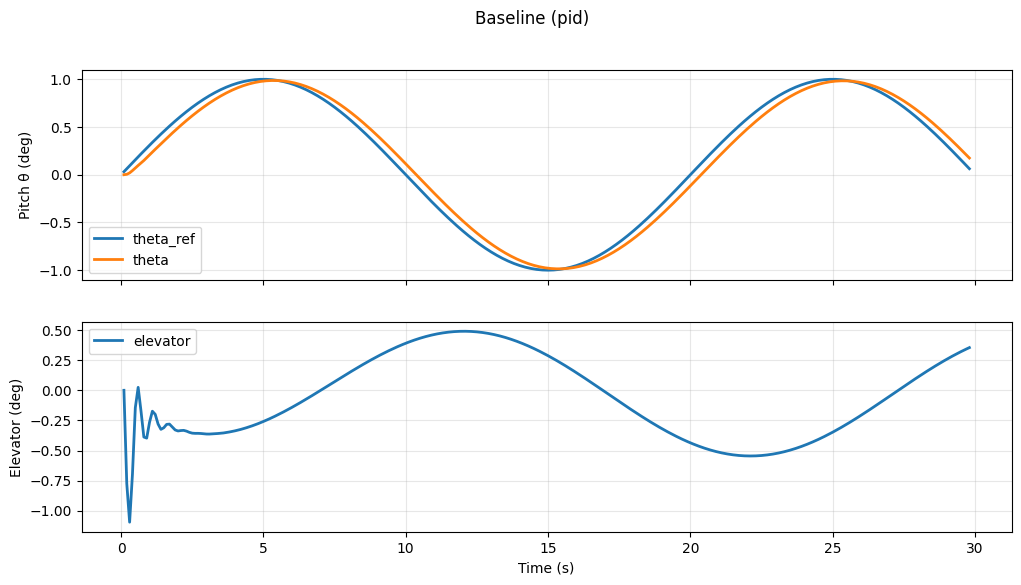

metrics: {'rmse_theta_deg': 0.08023503923903748, 'mae_theta_deg': 0.07220536125471365, 'max_abs_theta_deg': 0.11803107211676142, 'episode_return': -0.002675393092135713}
Training... episodes= 300 design= hdp


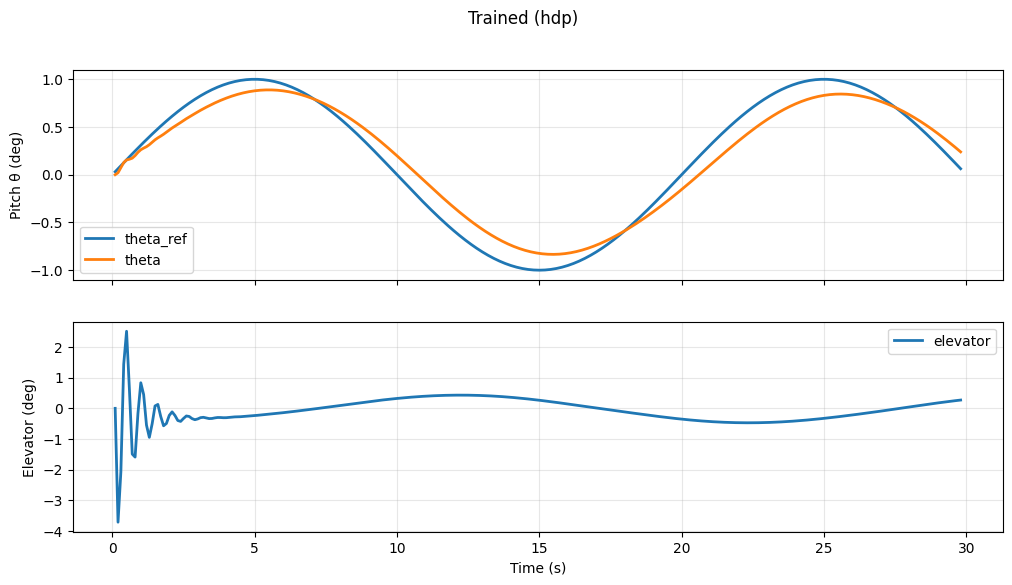

metrics: {'rmse_theta_deg': 0.15432988994917865, 'mae_theta_deg': 0.13648107262095902, 'max_abs_theta_deg': 0.2448096929095513, 'episode_return': -0.0099316310684696}


In [3]:
def make_env():
    return make_env_b747_sine(
        dt=DT,
        n_steps=N_STEPS,
        reward_mode=REWARD_MODE,
        sine_amp_deg=SINE_AMP_DEG,
        sine_freq_hz=SINE_FREQ_HZ,
    )

base_kind = DHP_BASELINE_TYPE if bool(DHP_USE_BASELINE) else "random"
baseline = rollout(
    make_env(),
    agent=None,
    baseline=base_kind,
    pid_kp=DHP_BASELINE_KP,
    pid_ki=DHP_BASELINE_KI,
    pid_kd=DHP_BASELINE_KD,
    pid_mode=DHP_PID_MODE,
    pd_kp=DHP_BASELINE_KP,
    pd_kd=DHP_BASELINE_KD,
)
plot_rollout(baseline, title=f"Baseline ({base_kind})")

agent = ADP(
    env=make_env(),
    design=DESIGN,
    gamma=GAMMA,
    actor_lr=ACTOR_LR,
    critic_lr=CRITIC_LR,
    hidden_size=HIDDEN_SIZE,
    device=DEVICE,
    exploration_std=EXPLORATION_STD,
    dhp_use_baseline=DHP_USE_BASELINE,
    dhp_baseline_type=DHP_BASELINE_TYPE,
    dhp_baseline_kp=DHP_BASELINE_KP,
    dhp_baseline_ki=DHP_BASELINE_KI,
    dhp_baseline_kd=DHP_BASELINE_KD,
    dhp_pid_mode=DHP_PID_MODE,
    dhp_residual_scale=DHP_RESIDUAL_SCALE,
    dhp_actor_delta_l2=DHP_ACTOR_DELTA_L2,
    dhp_critic_cycle_episodes=DHP_CRITIC_CYCLE_EPISODES,
    dhp_action_cycle_episodes=DHP_ACTION_CYCLE_EPISODES,
    log_every_updates=500,
)

print("Training...", "episodes=", TRAIN_EPISODES, "design=", DESIGN)
agent.train(num_episodes=int(TRAIN_EPISODES), max_steps=int(MAX_STEPS_PER_EPISODE))

trained = rollout(make_env(), agent=agent, deterministic=True)
plot_rollout(trained, title=f"Trained ({DESIGN})")

